<img src="../logo_UTN.svg" align="right" width="150" /> 

# Teoría De Circuitos 2

# Trabajo Semanal Nº10
#### Federico Borello

In [1]:
# SetUp - Import /utils module
import sys
import os

sys.path.append(os.path.abspath(".."))

# Import common packages
from IPython.display import display, Markdown
import sympy as sp

In [2]:
from IPython.display import HTML

file = "./TS10_handwritten.pdf"
html = f"""
<div style="text-align:center;">
    <iframe src="{file}" width="900" height="600"></iframe>
</div>
"""
HTML(html)

## Ejercicio 1

<div align=center>

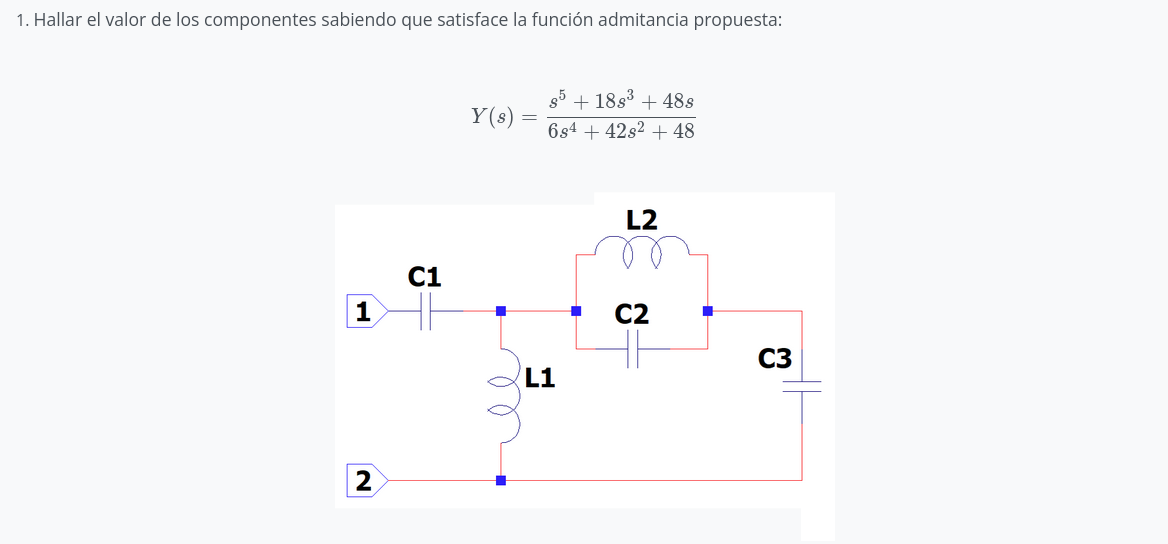

</div>

<IPython.core.display.Math object>

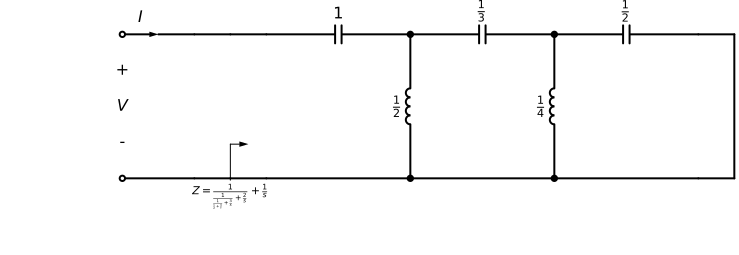

In [3]:
from pytc2.sintesis_dipolo import cauer_LC
from pytc2.dibujar import dibujar_cauer_LC
from pytc2.general import print_latex, a_equal_b_latex_s

s = sp.symbols("s", complex=True)

Y = (s**5 + 18 * s**3 + 48 * s) / (6 * s**4 + 42 * s**2 + 48)
Z = 1 / Y

# Cauer en 0 // Sintesis Canónica
ko, F_cauer_o, rem = cauer_LC(Z, remover_en_inf=False)
print_latex(a_equal_b_latex_s(a_equal_b_latex_s("F(s)", Z)[1:-1], F_cauer_o))
dibujar_cauer_LC(ko, z_exc=F_cauer_o)

## Ejercicio 2

<div align=center>

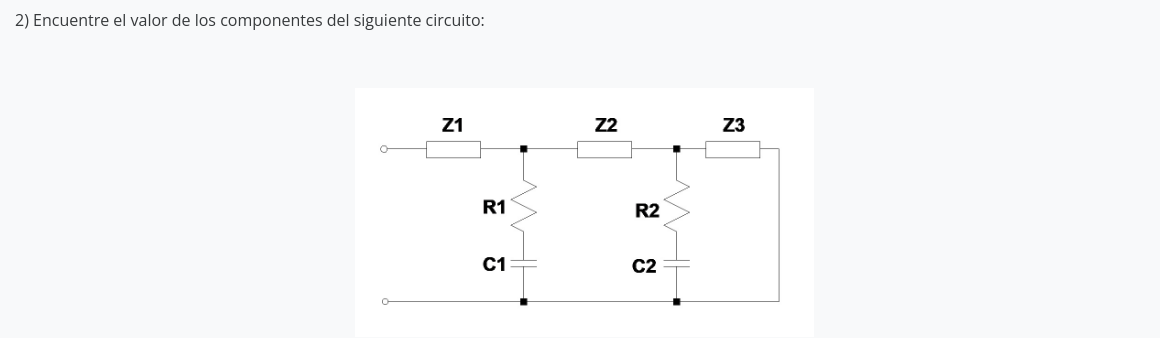

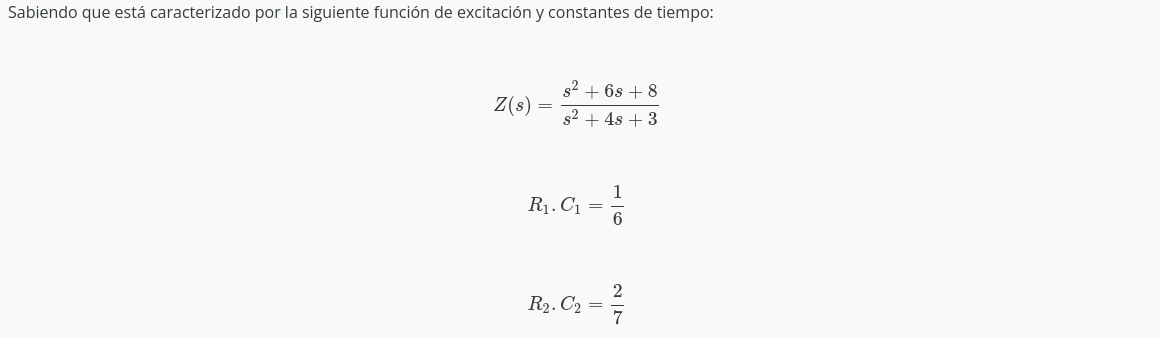

</div>

In [4]:
def R_and_C_from_k(k, tau):
    R = 1 / k
    C = k / tau
    return R, C


s = sp.symbols("s", complex=True)
Z = (s**2 + 6 * s + 8) / (s**2 + 4 * s + 3)
Y = 1 / Z

R1 = Z.subs(s, -6)
Z2 = Z - R1
Z2 = Z2.factor().simplify()

# Residuo en -6
Ya = 1 / Z2
k_6 = sp.limit(Ya * (s + 6) / s, s, -6)
Y_t1 = k_6 * s / (s + 6)
Yb = Ya - Y_t1
Yb = Yb.factor().simplify()

Z3 = 1 / Yb


R2 = Z3.subs(s, -sp.Rational(7, 2))
Z4 = Z3 - R2
Z4 = Z4.factor().simplify()

# Residuo en -7/2
Yc = 1 / Z4
k_7_2 = sp.limit(Yc * (s + sp.Rational(7, 2)) / s, s, -sp.Rational(7, 2))

Y_t2 = k_7_2 * s / (s + sp.Rational(7, 2))
Yd = Yc - Y_t2
Yd = Yd.factor().simplify()

Z5 = 1 / Yd

markdown_msg = f"""
### Expresión Inicial
$$Z(s) = {sp.latex(Z)}$$
$$Y(s) = {sp.latex(Y)}$$

### Primer Resistor
$$R_1 = Z(-6) = {sp.latex(R1)}$$

### Resto del circuito
$$Z_2(s) = Z(s) - R_1 = {sp.latex(Z2)}$$

### Primer Tanque RC
$$k_{6} = \\lim_{{s \\to -6}} Y_2(s) \\frac{{s + 6}}{{s}} = {sp.latex(k_6)}$$
$$Y_{{\\text{{tanque1}}}} = \\frac{{k_{6} s}}{{s + 6}} = {sp.latex(Y_t1)}$$

$$R_1, C_1 = (\\frac{{1}}{{k_{6}}}, k_{6} \, t_1 = 6) =  {sp.latex(R_and_C_from_k(k_6, 6))}$$

### Resto del circuito

$$Y_3(s) = Y_2(s) - Y_{{\\text{{tanque1}}}} = {sp.latex(Yb)}$$
$$Z_3(s) = \\frac{{1}}{{Y_3(s)}} = {sp.latex(Z3)}$$

### Segundo Resistor
$$R_2 = Z_3(-\\frac{{7}}{{2}}) = {sp.latex(R2)}$$

### Resto del circuito
$$Z_4(s) = Z_3(s) - R_2 = {sp.latex(Z4)}$$

### Segundo Tanque RC
$$k_{{\\frac{{7}}{{2}}}} = \\lim_{{s \\to -\\frac{{7}}{{2}}}} Y_4(s) \\frac{{s + \\frac{{7}}{{2}}}}{{s}} = {sp.latex(k_7_2)}$$
$$Y_{{\\text{{tanque2}}}} = \\frac{{k_{{\\frac{{7}}{{2}}}} s}}{{s + \\frac{{7}}{{2}}}} = {sp.latex(Y_t2)}$$

$$R_2, C_2 = (\\frac{{1}}{{k_{{\\frac{{7}}{{2}}}}}}, k_{{\\frac{{7}}{{2}}}} \, t_2 = \\frac{{7}}{{2}}) =  {sp.latex(R_and_C_from_k(k_7_2, sp.Rational(7,2)))}$$

## Resto del circuito // Resistor Final
$$Y_5(s) = Y_4(s) - Y_{{\\text{{tanque2}}}} = {sp.latex(Yd)}$$
$$Z_5(s) = \\frac{{1}}{{Y_5(s)}} = {sp.latex(Z5)}$$
"""
display(Markdown(markdown_msg))


### Expresión Inicial
$$Z(s) = \frac{s^{2} + 6 s + 8}{s^{2} + 4 s + 3}$$
$$Y(s) = \frac{s^{2} + 4 s + 3}{s^{2} + 6 s + 8}$$

### Primer Resistor
$$R_1 = Z(-6) = \frac{8}{15}$$

### Resto del circuito
$$Z_2(s) = Z(s) - R_1 = \frac{\left(s + 6\right) \left(7 s + 16\right)}{15 \left(s + 1\right) \left(s + 3\right)}$$

### Primer Tanque RC
$$k_6 = \lim_{s \to -6} Y_2(s) \frac{s + 6}{s} = \frac{75}{52}$$
$$Y_{\text{tanque1}} = \frac{k_6 s}{s + 6} = \frac{75 s}{52 \left(s + 6\right)}$$

$$R_1, C_1 = (\frac{1}{k_6}, k_6 \, t_1 = 6) =  \left( \frac{52}{75}, \  \frac{25}{104}\right)$$

### Resto del circuito

$$Y_3(s) = Y_2(s) - Y_{\text{tanque1}} = \frac{15 \left(17 s + 26\right)}{52 \left(7 s + 16\right)}$$
$$Z_3(s) = \frac{1}{Y_3(s)} = \frac{52 \left(7 s + 16\right)}{15 \left(17 s + 26\right)}$$

### Segundo Resistor
$$R_2 = Z_3(-\frac{7}{2}) = \frac{884}{1005}$$

### Resto del circuito
$$Z_4(s) = Z_3(s) - R_2 = \frac{312 \left(2 s + 7\right)}{67 \left(17 s + 26\right)}$$

### Segundo Tanque RC
$$k_{\frac{7}{2}} = \lim_{s \to -\frac{7}{2}} Y_4(s) \frac{s + \frac{7}{2}}{s} = \frac{4489}{4368}$$
$$Y_{\text{tanque2}} = \frac{k_{\frac{7}{2}} s}{s + \frac{7}{2}} = \frac{4489 s}{4368 \left(s + \frac{7}{2}\right)}$$

$$R_2, C_2 = (\frac{1}{k_{\frac{7}{2}}}, k_{\frac{7}{2}} \, t_2 = \frac{7}{2}) =  \left( \frac{4368}{4489}, \  \frac{4489}{15288}\right)$$

## Resto del circuito // Resistor Final
$$Y_5(s) = Y_4(s) - Y_{\text{tanque2}} = \frac{67}{84}$$
$$Z_5(s) = \frac{1}{Y_5(s)} = \frac{84}{67}$$


## Ejercicio 3

<div align=center>

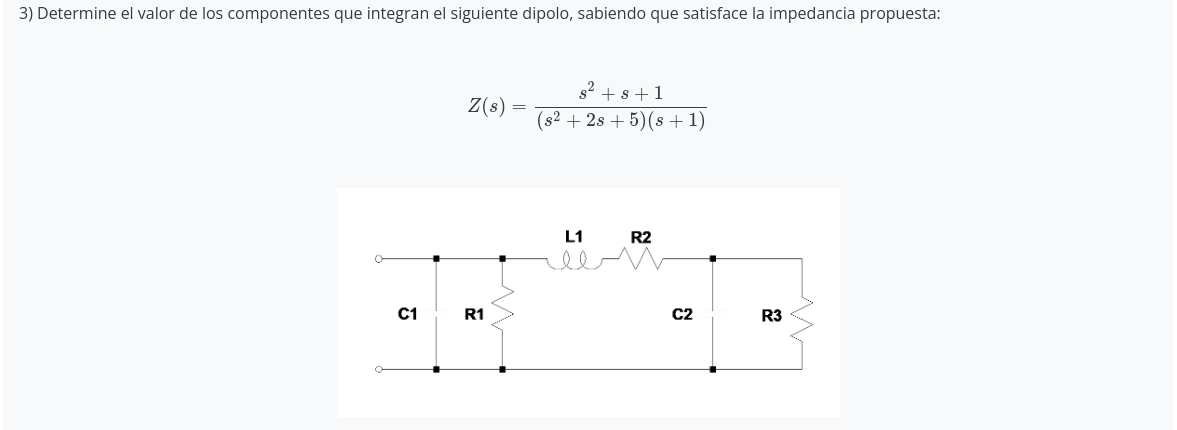

</div>

In [5]:
Z33 = (s**2 + s + 1)/((s**2 + 2*s + 5)*(s + 1))
Y33 = sp.together(1/Z33)

num, den = sp.together(Y33).as_numer_denom()
q, r = sp.div(sp.Poly(num, s), sp.Poly(den, s))

C1 = sp.Rational(q.as_expr().coeff(s, 1))
G1 = sp.Rational(q.as_expr().subs(s, 0))
R1 = sp.simplify(1/G1)

Yrem1 = sp.simplify(sp.Poly(r, s).as_expr()/sp.Poly(den, s).as_expr())
Zrem1 = sp.simplify(1/Yrem1)

num, den = sp.together(Zrem1).as_numer_denom()
q, r = sp.div(sp.Poly(num, s), sp.Poly(den, s))
L2 = sp.Rational(q.as_expr().coeff(s, 1))
R2 = sp.simplify(q.as_expr().subs(s, 0))

Yrem2 = sp.simplify(sp.Poly(r, s).as_expr()/sp.Poly(den, s).as_expr())

q, r = Yrem2.as_numer_denom()
G3 = r.coeff(s, 0) * 1/q.coeff(s, 0)
R3 = 1/G3
C3 = r.coeff(s, 1) * 1/q.coeff(s, 0)
print(C3)

markdown_msg = f"""
### Expresión Inicial
$$Z(s) = {sp.latex(Z33)}$$
$$Y(s) = {sp.latex(Y33)}$$

### Primer Paso, C1 y R1
$$C_1 = {sp.latex(C1)}$$
$$R_1 = {sp.latex(R1)}$$

### Segundo Paso, L2 y R2
$$L_2 = {sp.latex(L2)}$$
$$R_2 = {sp.latex(R2)}$$

### Tercer Paso, C3 y R3
$$C_3 = {sp.latex(C3)}$$
$$R_3 = {sp.latex(R3)}$$
"""
display(Markdown(markdown_msg))

64/13



### Expresión Inicial
$$Z(s) = \frac{s^{2} + s + 1}{\left(s + 1\right) \left(s^{2} + 2 s + 5\right)}$$
$$Y(s) = \frac{\left(s + 1\right) \left(s^{2} + 2 s + 5\right)}{s^{2} + s + 1}$$

### Primer Paso, C1 y R1
$$C_1 = 1$$
$$R_1 = \frac{1}{2}$$

### Segundo Paso, L2 y R2
$$L_2 = \frac{1}{4}$$
$$R_2 = \frac{1}{16}$$

### Tercer Paso, C3 y R3
$$C_3 = \frac{64}{13}$$
$$R_3 = \frac{13}{48}$$


## Ejercicio 1

<div align=center>

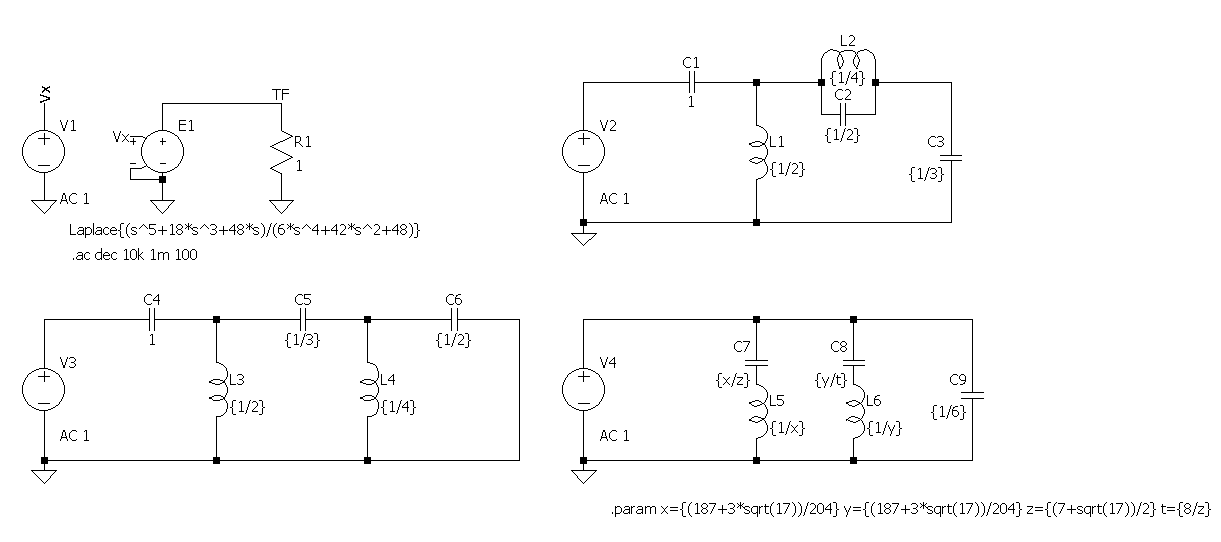

</div>

<a href="./TS10_1.asc" download="TS10_1.asc">Descargar TS10_1.asc</a>

<a href="./TS10_1.plt" download="TS10_1.plt">Descargar TS10_1.plt</a>

$$V = I \, Z $$
$$AC = 1 = V$$
$$Z = \cfrac{V}{I} \, \Rightarrow \, Y = I$$

$$-I(V2) = \text{Circuito de la consigna}$$
$$-I(V3) = \text{Circuito con método canónico a partir de fracciones sucesivas}$$
$$-I(V4) = \text{Circuito con método canónico a partir de fracciones simples}$$
$$V(\text{tf}) = Y(s) \quad \text{Especificada en el enunciado}$$

<div align=center>

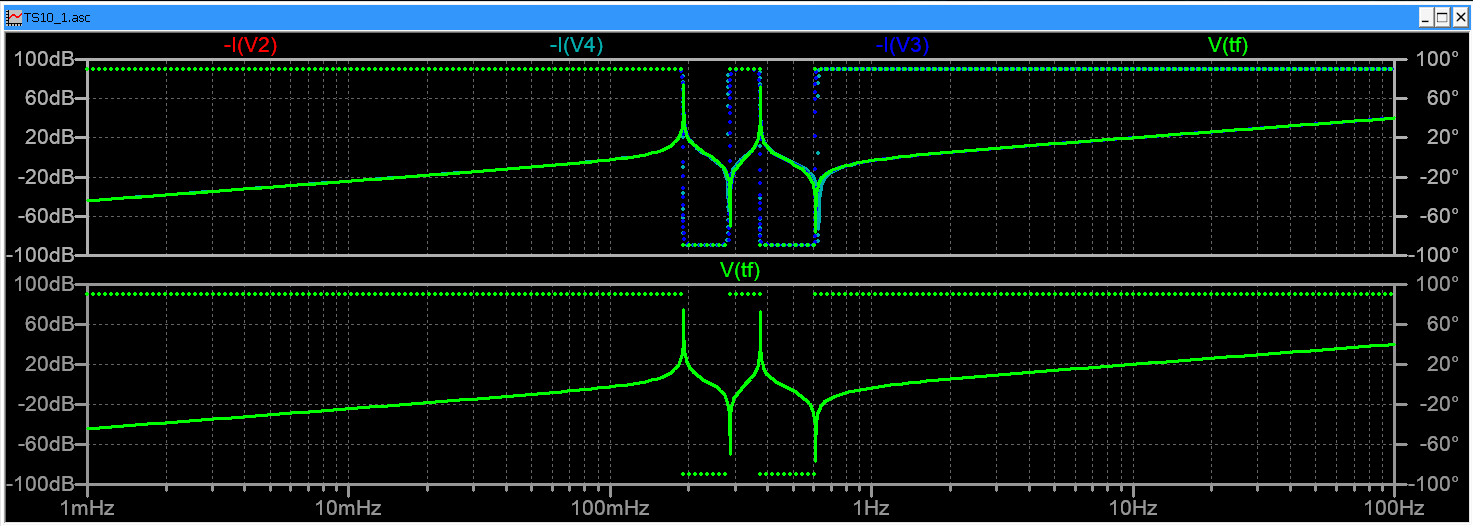

</div>

## Ejercicio 2

<div align=center>

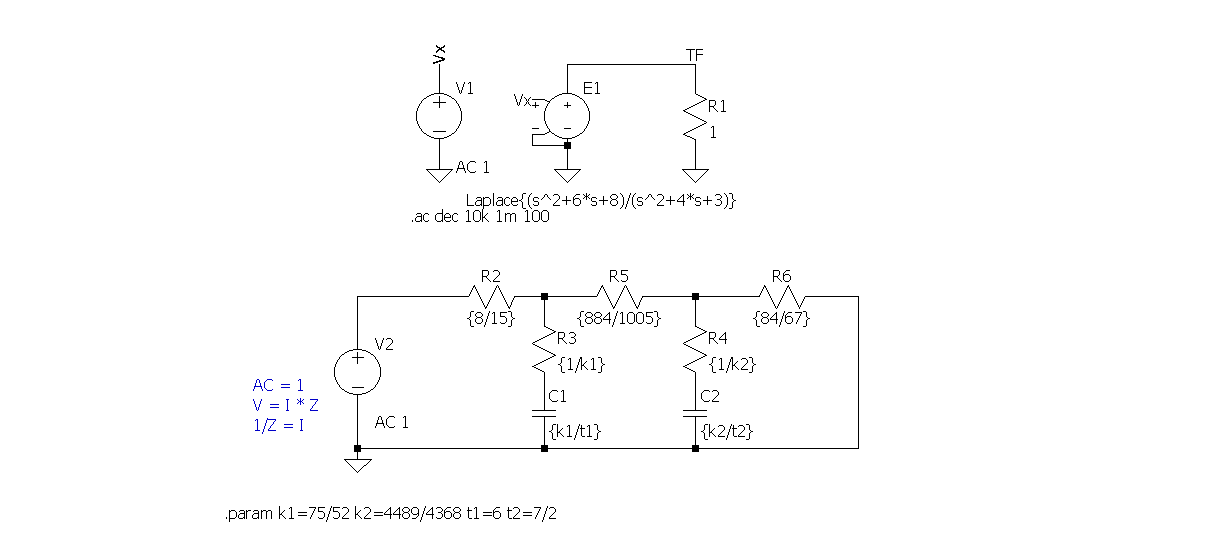

</div>

<a href="./TS10_2.asc" download="TS10_2.asc">Descargar TS10_2.asc</a>

<a href="./TS10_2.plt" download="TS10_2.plt">Descargar TS10_2.plt</a>

$$V = I \, Z $$
$$AC = 1 = V$$
$$Z = \cfrac{V}{I} = \cfrac{1}{I}$$

$$-I/(V2) = \text{Circuito de la consigna}$$
$$V(\text{tf}) = Z(s) \quad \text{Especificada en el enunciado}$$

<div align=center>

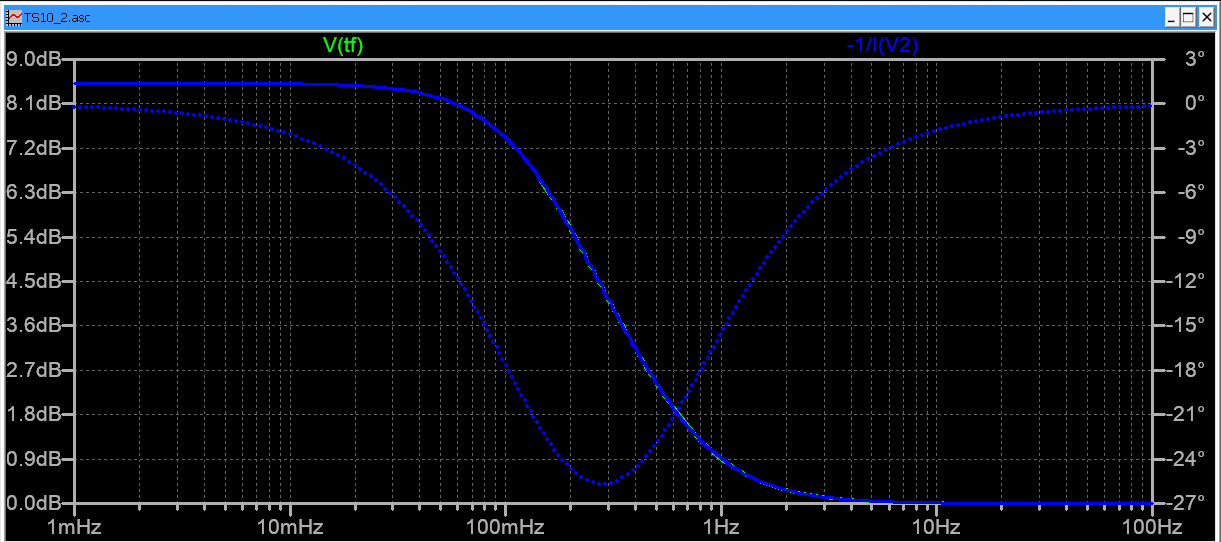

</div>

## Ejercicio 3

<div align=center>

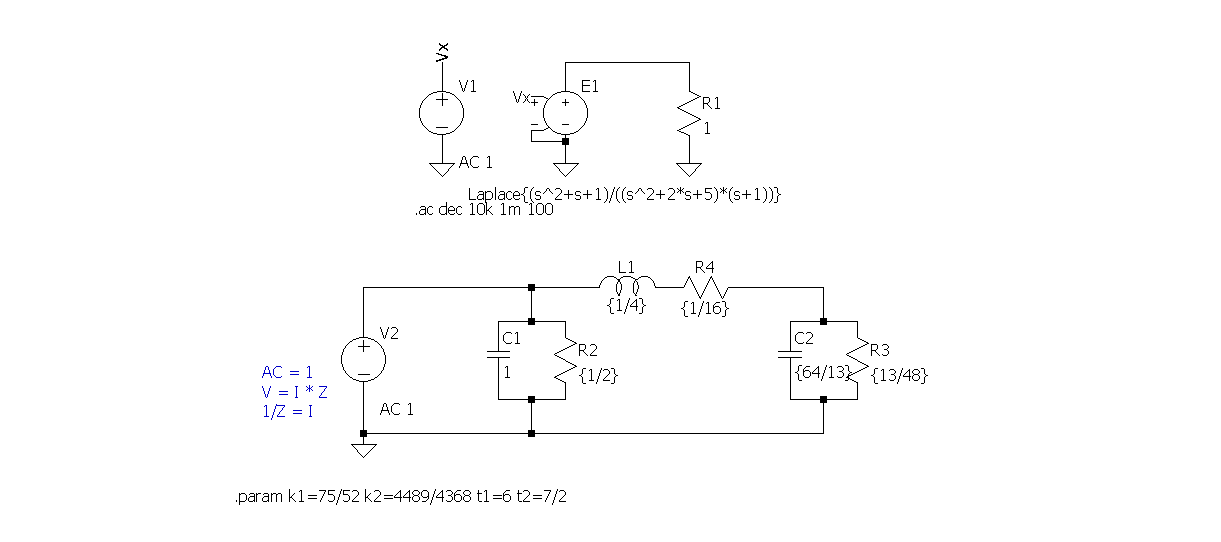

</div>

<a href="./TS10_3.asc" download="TS10_3.asc">Descargar TS10_3.asc</a>

<a href="./TS10_3.plt" download="TS10_3.plt">Descargar TS10_3.plt</a>

$$V = I \, Z $$
$$AC = 1 = V$$
$$Z = \cfrac{V}{I} = \cfrac{1}{I}$$

$$-I/(V2) = \text{Circuito de la consigna}$$
$$V(\text{tf}) = Z(s) \quad \text{Especificada en el enunciado}$$

<div align=center>

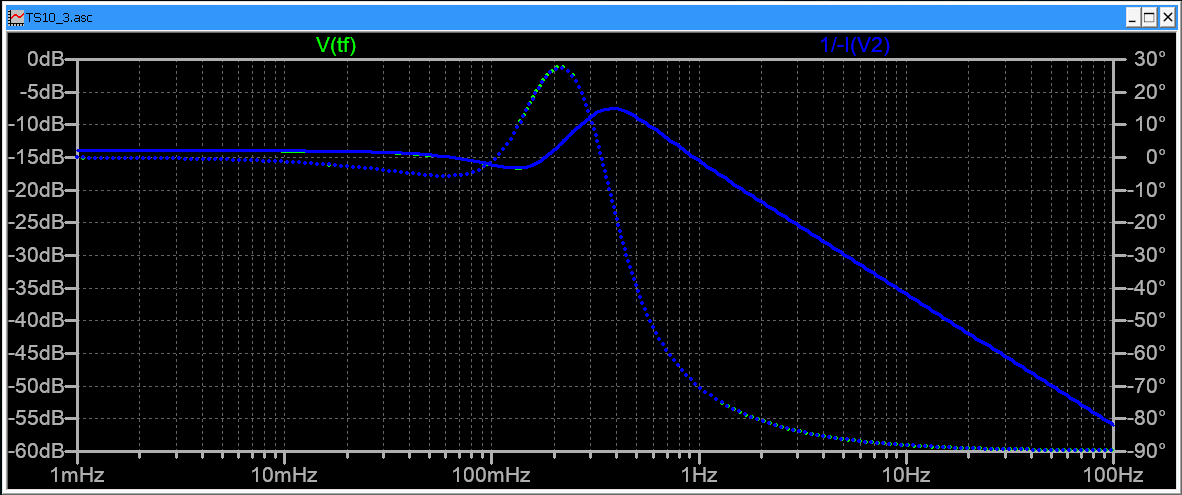

</div>